In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving blinkit.csv to blinkit.csv


In [3]:
df = pd.read_csv("blinkit.csv")

In [4]:
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [7]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


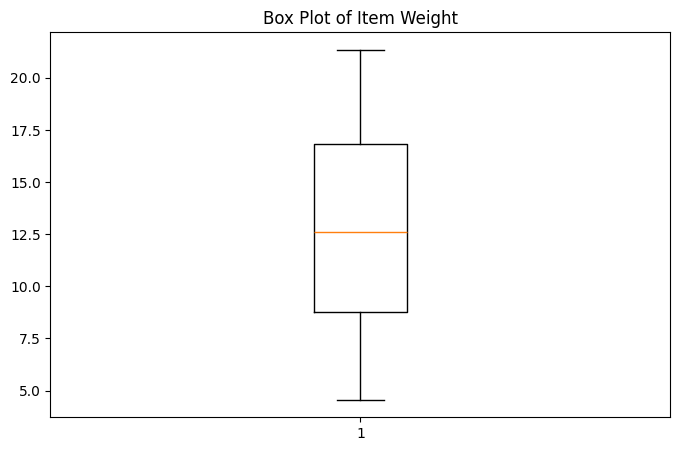

In [8]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Item_Weight'].dropna())
plt.title("Box Plot of Item Weight")
plt.show()

In [9]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [10]:
df['Item_Weight'].isnull().sum()

np.int64(0)

In [11]:
df['Outlet_Size'].mode()

,Outlet_Size
0,Medium


In [12]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [13]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [16]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [17]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [18]:
df.shape

(8523, 12)

In [19]:
df['Item_Outlet_Sales'].sum()

np.float64(18591125.4104)

In [20]:
df['Item_Outlet_Sales'].mean()

np.float64(2181.288913575032)

In [21]:
df['Item_Identifier'].count()

np.int64(8523)

In [22]:
fat_sales = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].sum()
fat_sales

,Item_Outlet_Sales
Item_Fat_Content,
Low Fat,1.190409e+07
Regular,6.687031e+06


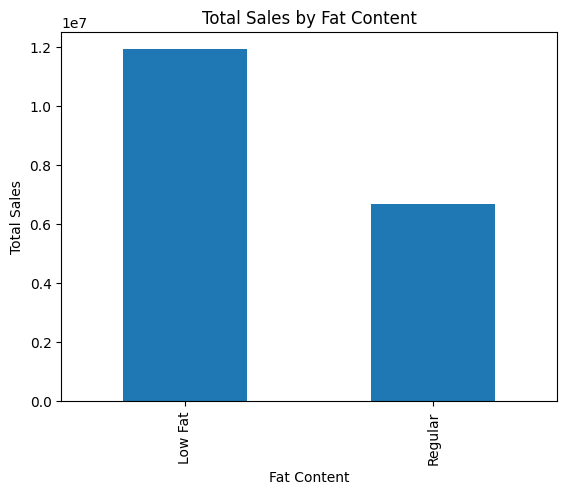

In [23]:
fat_sales.plot(kind='bar')

plt.title("Total Sales by Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Total Sales")

plt.show()

In [25]:
item_type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum()
item_type_sales

,Item_Outlet_Sales
Item_Type,
Baking Goods,1.265525e+06
Breads,5.532372e+05
Breakfast,2.322990e+05
Canned,1.444151e+06
Dairy,1.522594e+06
Frozen Foods,1.825735e+06
Fruits and Vegetables,2.820060e+06
Hard Drinks,4.577934e+05
Health and Hygiene,1.045200e+06


In [26]:
item_type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

item_type_sales

,Item_Outlet_Sales
Item_Type,
Fruits and Vegetables,2.820060e+06
Snack Foods,2.732786e+06
Household,2.055494e+06
Frozen Foods,1.825735e+06
Dairy,1.522594e+06
Canned,1.444151e+06
Baking Goods,1.265525e+06
Health and Hygiene,1.045200e+06
Meat,9.175656e+05


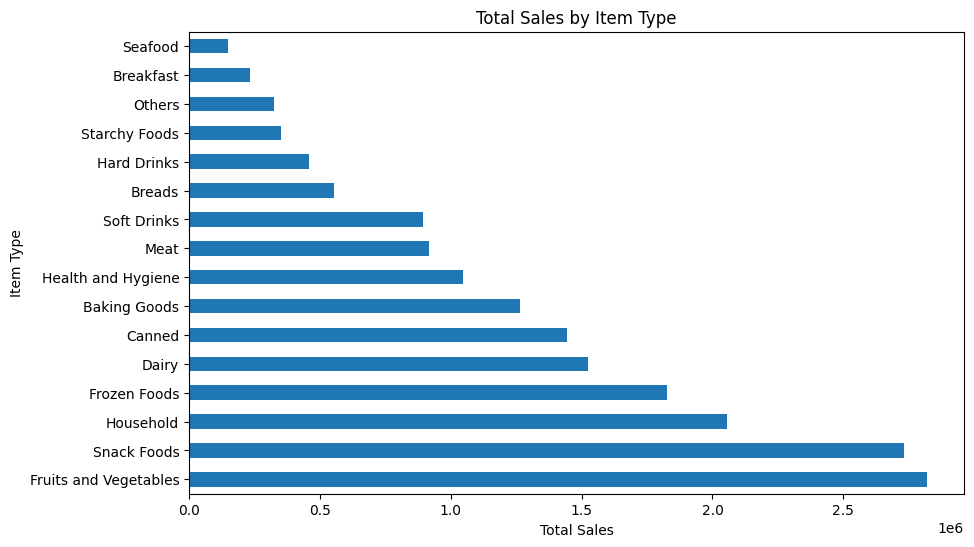

In [27]:
plt.figure(figsize=(10, 6))

item_type_sales.plot(kind='barh')

plt.title("Total Sales by Item Type")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")

plt.show()

In [28]:
outlet_size_sales = df.groupby('Outlet_Size')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

outlet_size_sales

,Item_Outlet_Sales
Outlet_Size,
Medium,1.188225e+07
Small,4.566212e+06
High,2.142664e+06


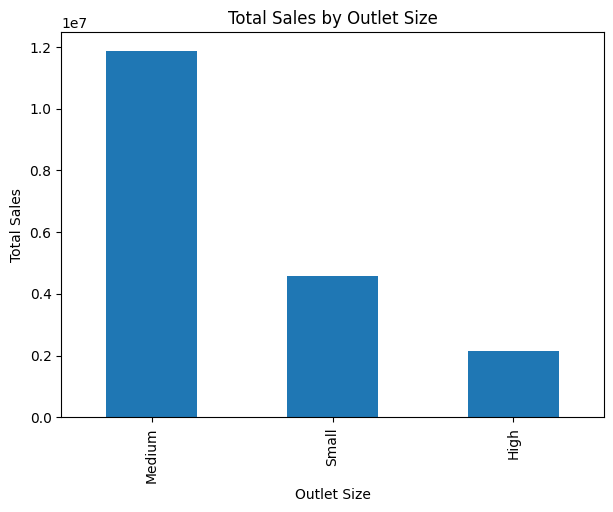

In [29]:
plt.figure(figsize=(7,5))

outlet_size_sales.plot(kind='bar')

plt.title("Total Sales by Outlet Size")
plt.xlabel("Outlet Size")
plt.ylabel("Total Sales")

plt.show()

In [30]:
outlet_location_sales = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

outlet_location_sales

,Item_Outlet_Sales
Outlet_Location_Type,
Tier 3,7.636753e+06
Tier 2,6.472314e+06
Tier 1,4.482059e+06


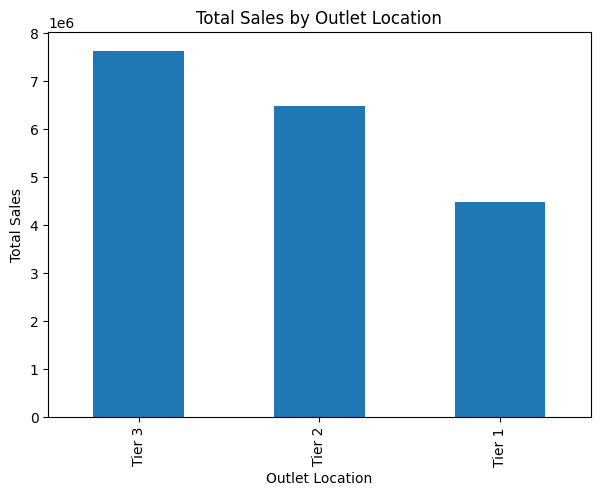

In [31]:
plt.figure(figsize=(7,5))

outlet_location_sales.plot(kind='bar')

plt.title("Total Sales by Outlet Location")
plt.xlabel("Outlet Location")
plt.ylabel("Total Sales")

plt.show()

In [32]:
outlet_type_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

outlet_type_sales

,Item_Outlet_Sales
Outlet_Type,
Supermarket Type1,1.291734e+07
Supermarket Type3,3.453926e+06
Supermarket Type2,1.851823e+06
Grocery Store,3.680343e+05


In [33]:
outlet_year_sales = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].sum().sort_values()

outlet_year_sales

,Item_Outlet_Sales
Outlet_Establishment_Year,
1998,1.883402e+05
2009,1.851823e+06
2002,2.036725e+06
1997,2.118395e+06
1987,2.142664e+06
2007,2.167465e+06
1999,2.183970e+06
2004,2.268123e+06
1985,3.633620e+06


In [34]:
top_products = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Item_Outlet_Sales
Item_Identifier,
FDY55,42661.8008
FDA15,41584.5364
FDZ20,40185.0248
FDF05,36555.7490
FDA04,35741.4756
FDK03,34843.9772
NCQ06,34680.1904
NCQ53,34508.4140
FDJ55,33531.0196


In [35]:
df[['Item_Weight', 'Item_MRP', 'Item_Outlet_Sales']].corr()

,Item_Weight,Item_MRP,Item_Outlet_Sales
Item_Weight,1.000000,0.024756,0.011550
Item_MRP,0.024756,1.000000,0.567574
Item_Outlet_Sales,0.011550,0.567574,1.000000


In [36]:
import seaborn as sns

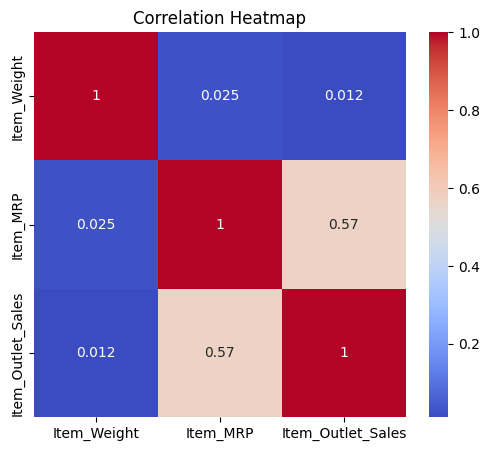

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['Item_Weight', 'Item_MRP', 'Item_Outlet_Sales']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()